# 10. Algorithmic Trading (SMA Crossover)

- **Objective**: Backtest a strategy, calculate Maximum Drawdown, Sharpe Ratio, and model transaction costs.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = yf.Ticker('SPY').history(start='2018-01-01', end='2024-01-01')['Close']

sma50 = data.rolling(window=50).mean()
sma200 = data.rolling(window=200).mean()

valid_idx = sma200.dropna().index
close = data.loc[valid_idx]
sma50 = sma50.loc[valid_idx]
sma200 = sma200.loc[valid_idx]

signals = pd.DataFrame(index=close.index)
signals['Signal'] = np.where(sma50 > sma200, 1.0, 0.0)
signals['Position'] = signals['Signal'].diff()

daily_returns = close.pct_change()
strategy_returns = daily_returns * signals['Signal'].shift(1)

cumulative_market = (1 + daily_returns).cumprod()
cumulative_strategy = (1 + strategy_returns).cumprod()

## Transaction Costs (Friction)

- Every trade costs money (slippage, bid-ask spread, commissions). Let's deduct 5 basis points (0.05%) for every trade executed.

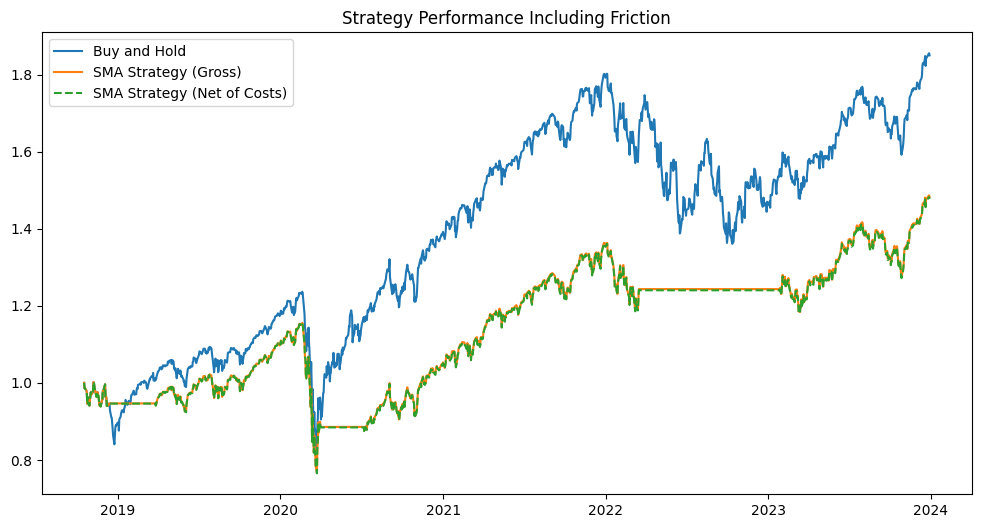

In [2]:
transaction_cost = 0.0005
# A trade happens whenever position changes (+1 or -1)
trades = abs(signals['Position'].shift(1).fillna(0))
strategy_returns_net = strategy_returns - (trades * transaction_cost)
cumulative_strategy_net = (1 + strategy_returns_net).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cumulative_market, label='Buy and Hold')
plt.plot(cumulative_strategy, label='SMA Strategy (Gross)')
plt.plot(cumulative_strategy_net, label='SMA Strategy (Net of Costs)', linestyle='--')
plt.title('Strategy Performance Including Friction')
plt.legend()
plt.show()

## Maximum Drawdown & Sharpe Ratio

- **Max Drawdown**: The largest peak-to-trough drop. It measures the pain of the strategy.
- **Sharpe Ratio**: Return per unit of risk ($ \frac{\mu}{\sigma} $).

In [3]:
def calculate_drawdown(cum_returns):
    running_max = np.maximum.accumulate(cum_returns.dropna())
    drawdown = (cum_returns / running_max) - 1
    return drawdown.min()

def calculate_sharpe(returns, risk_free_rate=0.0):
    excess_returns = returns.dropna() - (risk_free_rate / 252)
    return np.sqrt(252) * (excess_returns.mean() / excess_returns.std())

print('--- Buy and Hold ---')
print(f'Max Drawdown: {calculate_drawdown(cumulative_market):.2%}')
print(f'Sharpe Ratio: {calculate_sharpe(daily_returns):.2f}\n')

print('--- SMA Strategy (Net) ---')
print(f'Max Drawdown: {calculate_drawdown(cumulative_strategy_net):.2%}')
print(f'Sharpe Ratio: {calculate_sharpe(strategy_returns_net):.2f}')

--- Buy and Hold ---
Max Drawdown: -33.72%
Sharpe Ratio: 0.67

--- SMA Strategy (Net) ---
Max Drawdown: -33.72%
Sharpe Ratio: 0.53


## Questions for Understanding

- If a strategy has a very high return but a terrible Sharpe Ratio, what does that imply about the journey the portfolio took to get there?
- Why did the SMA strategy have a much smaller Maximum Drawdown than the Buy and Hold benchmark during this timeframe?